In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    if start is None: start = Path.cwd().resolve()
    start = start.resolve()
    for path in [start] + list(start.parents):
        if (path / "src").exists() and (path / "DATA").exists(): return path
    raise FileNotFoundError("Could not find repo root.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print(f"Project Root: {ROOT}")

pairs_path = ROOT / "results" / "training_window_data" / "tradable_pairs_by_window.csv"
pairs_matrix = pd.read_csv(pairs_path, index_col=0)

for col in pairs_matrix.columns:
    pairs_matrix[col] = pairs_matrix[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Stitch the timeline
regime_dir = ROOT / "results" / "testing_window_data"
regime_files = sorted(regime_dir.glob("regime_probabilities_*.csv"))
master_regimes = pd.concat([pd.read_csv(f) for f in regime_files], ignore_index=True)
master_regimes['test_date'] = pd.to_datetime(master_regimes['test_date'])
master_regimes = master_regimes.set_index('test_date').sort_index()

master_regimes = master_regimes[~master_regimes.index.duplicated(keep='last')]
print(f"Timeline Stitched: {master_regimes.index.min().date()} to {master_regimes.index.max().date()}")

Project Root: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526
Timeline Stitched: 2010-01-01 to 2025-12-31


In [ ]:
def run_bps_backtest(pair_id, pairs_matrix, master_regimes, cost_bps_per_trade=5.0):
    
    kalman_path = ROOT / "results" / "spreads" / f"{pair_id}.parquet"
    if not kalman_path.exists(): kalman_path = ROOT / "results" / "spreads" / f"{pair_id}_kalman.parquet"
    if not kalman_path.exists(): return pd.DataFrame()
            
    df = pd.read_parquet(kalman_path)
    df.index = pd.to_datetime(df['date'] if 'date' in df.columns else df.index)
    df = df.loc['2010-01-01':].copy()
    
    df = df.join(master_regimes[['regime_most_likely']], how='inner')
    allowed_map = pairs_matrix[pair_id].to_dict()
    df['allowed_regimes'] = df.index.map(lambda d: allowed_map.get(f"{d.year}-01-01", []))
    
    df['regime_allowed'] = df.apply(
        lambda row: isinstance(row['allowed_regimes'], list) and row['regime_most_likely'] in row['allowed_regimes'], 
        axis=1
    )
    
    # Setup Signals (T+1 Shift to prevent intraday lookahead)
    df['long_setup'] = (df['innovation_z_t'] <= -2.0).shift(1).fillna(False)
    df['short_setup'] = (df['innovation_z_t'] >= 2.0).shift(1).fillna(False)
    df['exit_setup'] = (df['innovation_z_t'].abs() <= 0.5).shift(1).fillna(False)
    df['forced_exit'] = (~df['regime_allowed']).shift(1).fillna(False)
    
    # Trade Ledger
    trade_log = []
    current_pos = 0
    entry_date, entry_price = None, 0
    
    for date, row in df.iterrows():
        # Exit Logic
        if current_pos != 0:
            exit_reason = None
            if row['exit_setup']: exit_reason = 'Mean Reversion'
            elif row['forced_exit']: exit_reason = 'Regime Shift (Forced)'
                
            if exit_reason:
                exit_price = row['spread_t']
                
                raw_pnl_bps = (exit_price - entry_price) * current_pos * 10000
                net_pnl_bps = raw_pnl_bps - cost_bps_per_trade
                
                trade_log.append({
                    'Pair': pair_id,
                    'Entry Year': entry_date.year,
                    'Entry Date': entry_date,
                    'Exit Date': date,
                    'Direction': 'Long' if current_pos == 1 else 'Short',
                    'Entry Spread': entry_price,
                    'Exit Spread': exit_price,
                    'Net PnL (bps)': net_pnl_bps,
                    'Holding Days': (date - entry_date).days,
                    'Exit Reason': exit_reason
                })
                current_pos = 0 
                
        # Entry Logic
        if current_pos == 0 and row['regime_allowed']:
            if row['long_setup']:
                current_pos = 1
                entry_date, entry_price = date, row['spread_t']
            elif row['short_setup']:
                current_pos = -1
                entry_date, entry_price = date, row['spread_t']
                
    # Mark-to-Market Fix (Close open trades on the last day of the year as regime definitions will change)
    if current_pos != 0:
        last_date = df.index[-1]
        last_price = df['spread_t'].iloc[-1]
        
        raw_pnl_bps = (last_price - entry_price) * current_pos * 10000
        net_pnl_bps = raw_pnl_bps - cost_bps_per_trade
        
        trade_log.append({
            'Pair': pair_id,
            'Entry Year': entry_date.year,
            'Entry Date': entry_date,
            'Exit Date': last_date,
            'Direction': 'Long' if current_pos == 1 else 'Short',
            'Entry Spread': entry_price,
            'Exit Spread': last_price,
            'Net PnL (bps)': net_pnl_bps,
            'Holding Days': (last_date - entry_date).days,
            'Exit Reason': 'End of Backtest (MTM)'
        })
                
    return pd.DataFrame(trade_log)

In [ ]:
all_pairs = pairs_matrix.columns.tolist()
all_trades = []

print("Executing Backtest across all pairs...")

for pair in all_pairs:
    trades = run_bps_backtest(pair, pairs_matrix, master_regimes, cost_bps_per_trade=5.0) 
    if not trades.empty:
        all_trades.append(trades)

if not all_trades:
    raise ValueError("No trades generated across any pairs! Check logic/data.")

master_ledger = pd.concat(all_trades, ignore_index=True)

# 1. Trades Per Year
trades_per_year = master_ledger.groupby('Entry Year').size().to_frame("Total Trades")
print("\n--- Trades Per Year ---")
display(trades_per_year)

# 2. Trades Per Pair
trades_per_pair = master_ledger.groupby('Pair').size().to_frame("Total Trades")
print("\n--- Trades Per Pair ---")
display(trades_per_pair)

# Save Master Ledger CSV for reference
out_dir = ROOT / "results" / "backtest"
out_dir.mkdir(parents=True, exist_ok=True)
master_ledger.to_csv(out_dir / "master_trade_ledger.csv", index=False)
print(f"Saved master ledger to: {out_dir / 'master_trade_ledger.csv'}")

Executing Backtest across all pairs...


C:\Users\kiefe\AppData\Local\Temp\ipykernel_2900\1461918302.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['long_setup'] = (df['innovation_z_t'] <= -2.0).shift(1).fillna(False)
C:\Users\kiefe\AppData\Local\Temp\ipykernel_2900\1461918302.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['short_setup'] = (df['innovation_z_t'] >= 2.0).shift(1).fillna(False)
C:\Users\kiefe\AppData\Local\Temp\ipykernel_2900\1461918302.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versi


--- Trades Per Year ---


C:\Users\kiefe\AppData\Local\Temp\ipykernel_2900\1461918302.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['long_setup'] = (df['innovation_z_t'] <= -2.0).shift(1).fillna(False)
C:\Users\kiefe\AppData\Local\Temp\ipykernel_2900\1461918302.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['short_setup'] = (df['innovation_z_t'] >= 2.0).shift(1).fillna(False)
C:\Users\kiefe\AppData\Local\Temp\ipykernel_2900\1461918302.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versi

,Total Trades
Entry Year,
2011,4
2012,1
2013,5
2014,1
2016,8
2017,1
2018,4
2019,2
2020,4



--- Trades Per Pair ---


,Total Trades
Pair,
JPY-AUD 10Y,2
JPY-AUD 5Y,2
USD-EUR 10Y,28
USD-EUR 5Y,22


Saved master ledger to: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\results\backtest\master_trade_ledger.csv


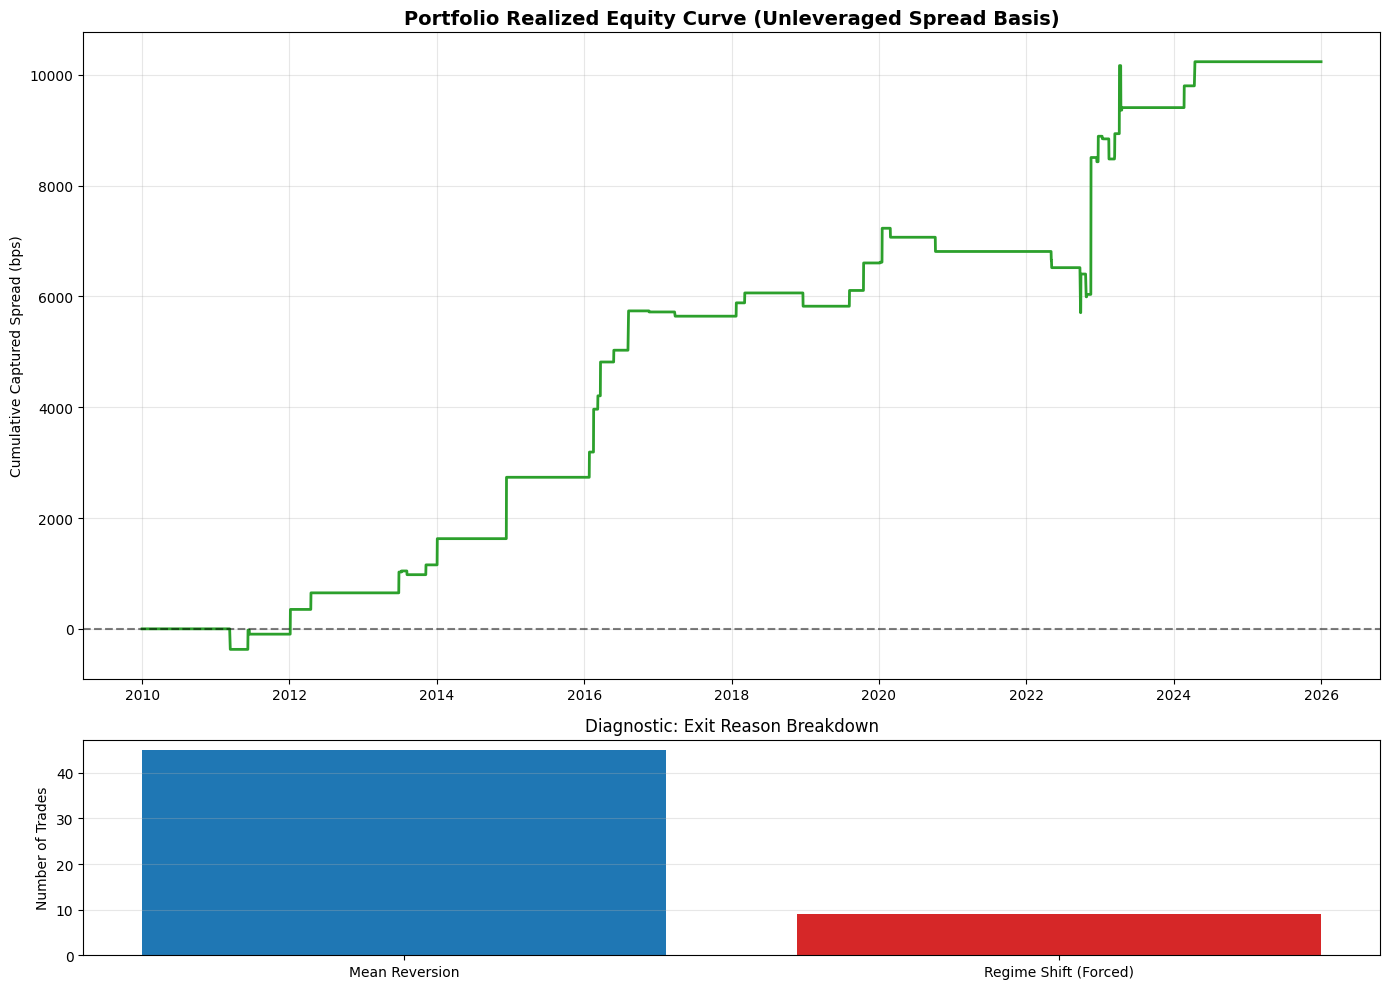

In [ ]:
# Aggregate PnL based on when the trade closed
pnl_timeline = master_ledger.groupby('Exit Date')['Net PnL (bps)'].sum().reset_index()
pnl_timeline = pnl_timeline.set_index('Exit Date').sort_index()

full_idx = pd.date_range(start='2010-01-01', end='2025-12-31', freq='B')
pnl_timeline = pnl_timeline.reindex(full_idx).fillna(0)
pnl_timeline['Cumulative PnL (bps)'] = pnl_timeline['Net PnL (bps)'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Cumulative Bps Curve
ax1.plot(pnl_timeline.index, pnl_timeline['Cumulative PnL (bps)'], color='#2ca02c', linewidth=2)
ax1.set_title("Portfolio Realized Equity Curve (Unleveraged Spread Basis)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Cumulative Captured Spread (bps)")
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)

# Trade Exits Diagnostics
exit_counts = master_ledger['Exit Reason'].value_counts()
ax2.bar(exit_counts.index, exit_counts.values, color=['#1f77b4', '#d62728'])
ax2.set_title("Diagnostic: Exit Reason Breakdown", fontsize=12)
ax2.set_ylabel("Number of Trades")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()